# Board Game Geek

Strona [boardgamesgeek](https://boardgamegeek.com/) ma 10-stopniową skalę oceniania gier planszowych. Gry oceniane są od 1 do 10, gdzie 1 oznacza najgorszą ocenę, a 10 najlepszą.

In [21]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from dotenv import load_dotenv
from time import sleep
from tqdm import tqdm
from random import random
import pandas as pd
import os

load_dotenv()
driver = webdriver.Chrome()

True

Logowanie na stronę jest wymagane, aby móc przeglądać wszystkie gry.

In [15]:
def setup(driver):
    driver.get("https://boardgamegeek.com/browse/boardgame")
    
    # Allow cookies on first visit
    driver.find_element(By.CLASS_NAME, "fc-cta-consent").click()
    
    # Login
    username = os.getenv('USER')
    password = os.getenv('PASS')
    driver.find_element(By.CSS_SELECTOR, "button[login-required]").click()
    driver.find_element(By.ID, "inputUsername").send_keys(username)
    driver.find_element(By.ID, "inputPassword").send_keys(password)
    driver.find_element(By.CSS_SELECTOR, "button[type=submit]").click()

Na każdej stronie wyświetlane jest 100 gier. W celu uzyskania wystarczającego zbioru danych do analizy, pobieramy dane ze 100 stron, co daje nam 10tys. gier.
Domyślnie gry są posortowane według oceny, zatem sortujemy je po liczbie ocen malejąco, aby uzyskać jak najbardziej wiarygodne wyniki.

In [16]:
def get_links(driver, from_file=True):
    if from_file:
        with open('links.txt', 'r') as f:
            links = f.readlines()
        return links
    
    links = []
    for page in tqdm(range(1, 101)):
        while True:
            driver.get(f'https://boardgamegeek.com/browse/boardgame/page/{page}?sort=numvoters&sortdir=desc')
            sleep(random())
            
            # Find all the links on the page
            anchors = driver.find_elements(By.CLASS_NAME, 'primary')
            if anchors:
                links += [link.get_attribute('href') for link in anchors]
                break

            # If the page is empty, wait and try again
            sleep(10)
    
    with open('links.txt', 'w') as f:
        for link in links:
            f.write(link + "\n")
    return links

In [17]:
setup(driver)

In [18]:
links = get_links(driver)

100%|██████████| 100/100 [05:50<00:00,  3.50s/it]


Zapisujemy następujące informacje na temat każdej gry:
1. Podstawowe informacje
   - Nazwa (name)
   - Rok wydania (year)
   - Opis (description)
   - Wymagana liczba graczy (min_players, max_players)
   - Czas gry (min_playtime, max_playtime)
   - Wymagany wiek (min_age)
   - Złożoność gry (complexity)
   - Alternatywne nazwy (alternate_names)
   - Designerzy (designers)
   - Artyści (artists)
   - Wydawcy (publishers)
2. Opinie
   - Liczba ocen (ratings)
   - Średnia ocena (avg_rating)
   - Odchylenie standardowe (std_rating)
   - Rozkład ocen (ratings_1, ratings_2, ..., ratings_10)
3. Statystyki gry
   - Liczba komentarzy (comments)
   - Liczba fanów (fans)
   - Wyświetlenia strony (page_views)
4. Statystyki rozgrywek
   - Liczba rozgrywek (plays)
   - Liczba rozgrywek w tym miesiącu (plays_month)
5. Dane na temat posiadania gry
   - Liczba osób posiadających grę (owners)
   - Liczba osób, które posiadały grę (prev_owned)
   - Liczba osób, które chcą sprzedać grę (for_trade)
   - Liczba osób, które chcą kupić grę (want_in_trade)
   - Liczba osób, które mają grę na liście życzeń (wishlist)

In [114]:
def get_property(driver, selector, attribute='text', convert=None):
    try:
        if attribute == 'text':
            result = driver.find_element(By.CSS_SELECTOR, selector).text
        else:
            result = driver.find_element(By.CSS_SELECTOR, selector).get_attribute(attribute)
        
        if convert:
            return convert(result)
        return result
    except:
        return None

def get_game(driver, link):
    driver.get(link + '/stats')
    sleep(random() * 8 + 2) # Sleep between 2 and 10 seconds
    game = {}

    # Basic info
    game['name'] = get_property(driver, 'span[itemprop="name"]')
    game['year'] = get_property(driver, 'span.game-year', convert=lambda x: x.strip('()'))
    game['description'] = get_property(driver, 'span[itemprop="description"]')
    game['min_players'] = get_property(driver, '[itemprop="numberOfPlayers"] meta[itemprop="minValue"]', 'content')
    game['max_players'] = get_property(driver, '[itemprop="numberOfPlayers"] meta[itemprop="maxValue"]', 'content')
    play_time = get_property(driver, 'ul.gameplay > li:nth-child(2) > p > span > span', convert=lambda x: x.split('–'))
    game['min_play_time'] = play_time[0] if play_time else None
    game['max_play_time'] = play_time[-1] if play_time else None
    game['min_age'] = get_property(driver, 'span[itemprop="suggestedMinAge"]')
    game['complexity'] = get_property(driver, '[item-poll-button="boardgameweight"] > span')

    # Credits
    alternate_names = driver.find_elements(By.CSS_SELECTOR, 'span[itemprop="alternateName"]')
    game['alternate_names'] = [name.text for name in alternate_names]
    designers = driver.find_elements(By.CSS_SELECTOR, 'span[itemprop="creator"]')
    game['designers'] = [name.text for name in designers]
    artists = driver.find_elements(By.CSS_SELECTOR, 'div.game-header-credits > ng-include > div > ul > li:nth-child(3) > popup-list > span.ng-scope > a > span')
    game['artists'] = [name.text for name in artists]
    publishers = driver.find_elements(By.CSS_SELECTOR, 'span[itemprop="publisher"]')
    game['publishers'] = [name.text for name in publishers]

    # Stats
    titles = {
        'Avg. Rating': 'avg_rating',
        'No. of Ratings': 'ratings',
        'Std. Deviation': 'std_rating',
        'Comments': 'comments',
        'Fans': 'fans',
        'Page Views': 'page_views',
        'All Time Plays': 'plays',
        'This Month': 'plays_month',
        'Own': 'owners',
        'Prev. Owned': 'prev_owned',
        'For Trade': 'for_trade',
        'Want In Trade': 'want_in_trade',
        'Wishlist': 'wishlist'
    }
    for elem in driver.find_elements(By.CLASS_NAME, 'outline-item'):
        title = get_property(elem, '.outline-item-title')
        if title in titles:
            game[titles[title]] = get_property(elem, '.outline-item-description',
                                               convert=lambda x: x.split('\n')[0].replace(',', ''))

    # Rank distribution
    ratings = driver.find_elements(By.CSS_SELECTOR, 'ratings-stats-graph > div > div > div:nth-child(1) > div > div > table > tbody > tr > td:nth-child(2)')
    for i, elem in enumerate(ratings):
        try:
            game['ratings_' + str(i+1)] = elem.get_attribute('innerHTML').replace(',', '')
        except:
            game['ratings_' + str(i+1)] = None
    
    return game

def read_games():
    columns = ['name', 'year', 'description',
        'min_players', 'max_players', 'min_play_time',
        'max_play_time', 'min_age', 'complexity',
        'alternate_names', 'designers', 'artists',
        'publishers', 'ratings', 'avg_rating',
        'std_rating', 'ratings_1', 'ratings_2',
        'ratings_3', 'ratings_4', 'ratings_5',
        'ratings_6', 'ratings_7', 'ratings_8',
        'ratings_9', 'ratings_10', 'comments',
        'fans', 'page_views', 'plays', 'plays_month',
        'owners', 'prev_owned', 'for_trade',
        'want_in_trade', 'wishlist']
    try:
        df = pd.read_csv('games.csv')
        eval_columns = ['alternate_names', 'designers', 'artists', 'publishers']
        df[eval_columns] = df[eval_columns].map(eval)
    except FileNotFoundError:
        df = pd.DataFrame(columns=columns)
    return df

In [115]:
limit = 50

df = read_games()
offset = len(df)
for link in tqdm(links[offset:offset+limit]):
    df.loc[len(df)] = get_game(driver, link)
    if len(df) % 10 == 0 or len(df) == offset + limit:
        df.to_csv('games.csv', index=False)

  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [04:38<00:00,  8.19s/it]


In [118]:
driver.quit()

In [117]:
from scraper import Scraper, read_games
scraper = Scraper()
scraper.get_games(games=51)

100%|██████████| 51/51 [06:23<00:00,  7.53s/it]


# Analiza danych

In [116]:
from matplotlib import pyplot as plt

df = read_games()
df

,name,year,description,min_players,max_players,min_play_time,max_play_time,min_age,complexity,alternate_names,...,comments,fans,page_views,plays,plays_month,owners,prev_owned,for_trade,want_in_trade,wishlist
0,CATAN,1995,Collect and trade resources to build up the is...,3,4,60.0,120.0,10,2.29,"[Catan, The Settlers of Catan]",...,22457,7373,4896994,386201,1096,215312,14663,2252,514,7248
1,Carcassonne,2000,"Shape the medieval landscape of France, claimi...",2,5,30.0,45.0,7,1.89,[Carcassonne Jubilee Edition],...,22016,7871,4985713,661921,1975,201471,11925,1993,658,9581
2,Pandemic,2008,Your team of experts must prevent the world fr...,2,4,45.0,45.0,8,2.40,"[EPIZOotic, Pandemic: 10th Anniversary Edition]",...,19795,8051,4881851,427887,594,209259,15111,3202,614,10848
3,7 Wonders,2010,Draft cards to develop your ancient civilizati...,2,7,30.0,30.0,10,2.32,[7 csoda],...,16633,7190,5091400,611521,1137,145701,11829,1902,982,14151
4,Terraforming Mars,2016,Compete with rival CEOs to make Mars habitable...,1,5,120.0,120.0,12,3.27,[A Mars terraformálása],...,14561,10951,9200428,675632,3308,143269,7415,779,1917,24480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,BANG! The Dice Game,2013,A wild west elimination dice game with secret ...,3,8,15.0,15.0,8,1.28,[Bang: Jocul de Zaruri],...,4505,681,888735,117140,160,40360,3843,791,256,3103
145,Skull,2011,"Does the token hide a flower or skull? Bid, bl...",3,6,15.0,45.0,10,1.12,"[Skull & Roses, Skull & Roses Red]",...,3883,819,1099647,128651,523,39912,2053,300,436,4617
146,Star Wars: Imperial Assault,2014,Play as Rebel or Imperial forces to fulfill mi...,2,5,60.0,120.0,14,3.30,[Star Wars: Assalto Imperiale],...,3833,3304,4232048,93875,87,43040,4310,742,792,7333
147,Twilight Imperium: Fourth Edition,2017,"Build an intergalactic empire through trade, r...",3,6,240.0,480.0,14,4.33,[Twilight Imperium: 4. kiadás],...,3712,3215,4006053,44450,198,30251,1523,206,1048,11892


In [110]:
df.describe()

,year,min_players,max_players,min_play_time,max_play_time,min_age,complexity,ratings,avg_rating,std_rating,...,comments,fans,page_views,plays,plays_month,owners,prev_owned,for_trade,want_in_trade,wishlist
count,200.000000,200.000000,200.000000,199.000000,199.000000,200.000000,200.000000,200.00000,200.000000,200.000000,...,200.000000,200.000000,2.000000e+02,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2007.065000,1.940000,6.180000,50.613065,83.854271,11.105000,2.448600,39277.86000,7.472665,1.374950,...,6487.600000,2483.525000,2.587029e+06,180272.460000,572.18500,58270.725000,5116.230000,796.985000,740.580000,7429.990000
std,39.562695,0.754484,9.807063,33.570310,89.269278,2.315336,0.874836,21537.16198,0.594422,0.173541,...,3313.037476,1999.017392,1.717530e+06,159504.636376,754.76617,34080.827644,2347.289922,473.628286,440.964468,4584.418024
min,1475.000000,1.000000,1.000000,5.000000,10.000000,6.000000,1.040000,20942.00000,4.360000,1.100000,...,2621.000000,403.000000,5.846330e+05,31049.000000,19.00000,23750.000000,1471.000000,163.000000,28.000000,394.000000
25%,2008.000000,1.000000,4.000000,30.000000,30.000000,10.000000,1.755000,24721.75000,7.192750,1.250000,...,4260.000000,1145.000000,1.453756e+06,80633.500000,139.75000,37196.250000,3459.250000,450.750000,407.750000,4387.500000
50%,2012.000000,2.000000,5.000000,45.000000,60.000000,12.000000,2.330000,32128.00000,7.529000,1.340000,...,5614.500000,1776.500000,2.006176e+06,117953.500000,310.50000,45917.000000,4707.500000,677.000000,657.500000,6521.500000
75%,2016.000000,2.000000,6.000000,60.000000,120.000000,13.000000,3.052500,47208.00000,7.807250,1.470000,...,7244.000000,3322.750000,3.346172e+06,215288.500000,644.25000,70653.750000,6211.500000,1018.000000,1061.250000,9864.750000
max,2022.000000,5.000000,100.000000,240.000000,1000.000000,17.000000,4.440000,131155.00000,8.589000,2.100000,...,22457.000000,10951.000000,1.325429e+07,837775.000000,5726.00000,215312.000000,15111.000000,3202.000000,1983.000000,24480.000000


In [113]:
df.dtypes

name                object
year                 int64
description         object
min_players          int64
max_players          int64
min_play_time      float64
max_play_time      float64
min_age              int64
complexity         float64
alternate_names     object
designers           object
artists             object
publishers          object
ratings              int64
avg_rating         float64
std_rating         float64
ratings_1          float64
ratings_2          float64
ratings_3          float64
ratings_4          float64
ratings_5          float64
ratings_6          float64
ratings_7          float64
ratings_8          float64
ratings_9          float64
ratings_10         float64
comments             int64
fans                 int64
page_views           int64
plays                int64
plays_month          int64
owners               int64
prev_owned           int64
for_trade            int64
want_in_trade        int64
wishlist             int64
dtype: object

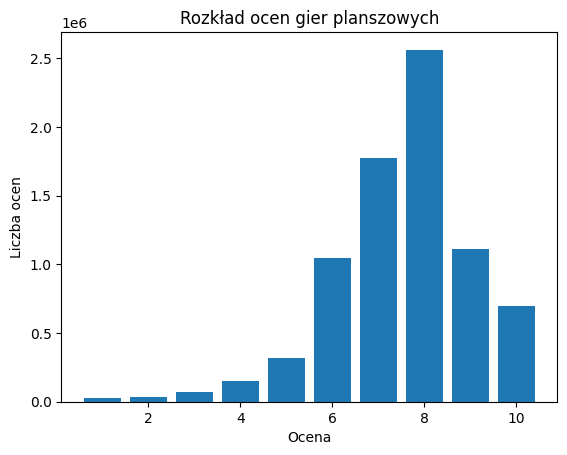

In [112]:
# Rozkład ocen
ratings = [f'ratings_{i}' for i in range(1, 11)]
ratings = df[ratings].sum()
ratings / ratings.sum()

plt.bar(list(range(1, 11)), ratings)
plt.xlabel('Ocena')
plt.ylabel('Liczba ocen')
plt.title('Rozkład ocen gier planszowych')
plt.show()